In [1]:
import os, sys, json
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
matplotlib.rcParams ['pdf.fonttype'] = 42
matplotlib.rcParams ['ps.fonttype'] = 42

sys.path.append("..")
# read from json
data = None
figure_name_prefix = "../figures/"

figure_name_suffix = "training"

data_paths = ["../../../output/oscar-nsdi26/experiments/fig12/sl64-ring-200g-os2-ResNet/",
              "../../../output/oscar-nsdi26/experiments/fig12/sl64-ring-200g-os2-VGG/", 
              "../../../output/oscar-nsdi26/experiments/fig12/sl64-a2a-200g-os2/",
              "../../../output/oscar-nsdi26/experiments/fig12/sl64-a2a-200g-os2-spray/"]
experiment_names = [
    "oscar", "hpcc", "hpcc-target1.5", "powertcp-12", "theta-powertcp", "poseidon"
]
experiment_suffix = ""
slowdowns = [[] for i in range(len(experiment_names))]
base_flows = []

for exp_idx, experiment_name in enumerate(experiment_names):

    flowscnt = []
    for data_path in data_paths:
        with open(data_path + experiment_name + experiment_suffix + ".json", "r") as f:
            data = json.load(f)

        # group data:"flowStatistics":[:] by data:"flowStatistics":"flowType"
        # we have eight flow type, from 0 prio to 7 prio
        flow_types = [str(i) + "group" for i in range(4)]
        flows = [[] for i in range(len(flow_types))]
        for flow in data["flowStatistics"]:
            # find the index of src_addr
            flow_type = flow["flowType"]
            index = flow_types.index(flow_type)
            flows[index].append(flow)

        # flowscnt = each flows.size
        temp = np.asarray([len(flow) for flow in flows])
        flowscnt.append(temp.sum())

    if experiment_names[0] == experiment_name:
        base_flows = flowscnt
    print(experiment_name, flowscnt)
    
    for index, scnt in enumerate(flowscnt):
        slowdowns[exp_idx].append(float(base_flows[index] / scnt))


oscar [1462, 394, 976, 1120]
hpcc [1345, 373, 832, 64]
hpcc-target1.5 [1410, 387, 896, 64]
powertcp-12 [1274, 360, 864, 475]
theta-powertcp [1215, 328, 928, 864]
poseidon [1416, 382, 944, 1104]


In [2]:
for exp_idx, experiment_name in enumerate(experiment_names):
    print(experiment_name, slowdowns[exp_idx])

oscar [1.0, 1.0, 1.0, 1.0]
hpcc [1.0869888475836431, 1.0563002680965148, 1.1730769230769231, 17.5]
hpcc-target1.5 [1.0368794326241135, 1.0180878552971577, 1.0892857142857142, 17.5]
powertcp-12 [1.1475667189952905, 1.0944444444444446, 1.1296296296296295, 2.357894736842105]
theta-powertcp [1.2032921810699588, 1.201219512195122, 1.0517241379310345, 1.2962962962962963]
poseidon [1.0324858757062148, 1.031413612565445, 1.0338983050847457, 1.0144927536231885]


[0, 1, 2, 3, 4, 5]


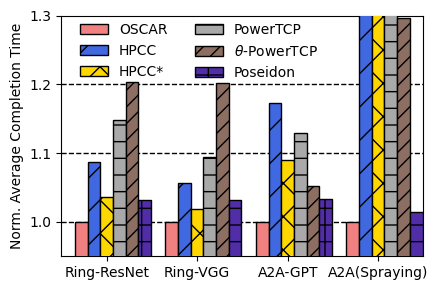

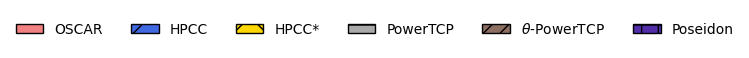

In [3]:

fig, ax = plt.subplots(1, 1, figsize=(4.5, 3))
num_groups = 4
num_bars_per_group = len(experiment_names)
bar_width = 0.14
group_positions = np.arange(num_groups)
offset = (num_bars_per_group-2) / 2 * bar_width
bar_positions = [group_positions - offset + i * bar_width for i in range(num_bars_per_group)]

labels = ["OSCAR", "HPCC", "HPCC*", "PowerTCP", "$\\theta$-PowerTCP", "Poseidon"]
hatches = ['', '/', 'x', '-', '//', '+', '|', '*']
colors = ['#f18181', '#4068e1', '#ffd700', '#a9a9a9', '#8D6E63', '#512DA8', '#228b22', '#F2C3A7']

index = 0
print(list(range(len(experiment_names))))
exp_is = list(range(len(experiment_names)))
for bar_idx, i in enumerate(exp_is):
    plt.bar(bar_positions[index], [s for s in slowdowns[i]][:num_groups],
            width=bar_width, linestyle='-', edgecolor='black', hatch=hatches[index], color=colors[index], alpha=1, label=labels[bar_idx], zorder = 1111)
    index += 1

ax.set_ylabel("Norm. Average Completion Time")
ax.set_xticks(group_positions)
# xticklabels = ["ResNet", "VGG", "GPT", "GPT w/ Spraying"]
xticklabels = ["Ring-ResNet", "Ring-VGG", "A2A-GPT", "A2A(Spraying)"]
# ax.text(0.5, 0.91, f'All-reduce', ha='center', va='top', transform=ax.transData)
# ax.text(2.5, 0.91, f'All-to-all', ha='center', va='top', transform=ax.transData)
ax.set_xticklabels(xticklabels)
ax.set_yticks([1.0, 1.1, 1.2, 1.3])
ax.set_ylim(0.95, 1.3)
ax.set_xlim(-0.5, 3.5)
# add grid但是不用覆盖bar
# ax.grid(axis='y', linestyle='--', zorder = 0)
# 加一条y=1的横线
ax.axhline(y=1, color='black', linewidth=1, linestyle='--')
ax.axhline(y=1.1, color='black', linewidth=1, linestyle='--')
ax.axhline(y=1.2, color='black', linewidth=1, linestyle='--')
plt.legend(loc='center', bbox_to_anchor=(0.38, 0.85), ncol=2, frameon=False)
plt.tight_layout()

# plt.savefig(figure_name_prefix + figure_name_suffix +
#             "-Avg&P99inOne.jpg", bbox_inches='tight', dpi=600, format='jpg')
plt.savefig(figure_name_prefix + figure_name_suffix +
            "-Avg&P99inOne.pdf", bbox_inches='tight', dpi=600, format='pdf')

fig_legend, ax_legend = plt.subplots(1, 1, figsize=(6, 0.5))
ax_legend.axis('off')
# ax_legend.legend(handles = [plt.Line2D([0], [0], color=colors[i], label=labels[i]) for i in range(len(labels))], loc='center', ncol=3)
ax_legend.legend(*ax.get_legend_handles_labels(), loc='center', ncol=len(experiment_names), frameon=False)
fig_legend.savefig(figure_name_prefix + figure_name_suffix +
            "-Avg&P99inOne" + "-legend.pdf", bbox_inches='tight', dpi=600, format='pdf')